# Cell Segmentation (10x HD)

Space Ranger v4.0 introduced nucleus and cell segmentation for Visium HD Spatial Gene Expression and Visium HD 3' Spatial Gene Expression.

At the same time, the community has produced several useful alternatives for high-resolution cell segmentation, including StarDist and Cellpose. The original bin2cell workflow integrated StarDist; here we keep the same overall bin2cell idea but rewrite the segmentation stage around the Python-based Cellpose backend so the full workflow can stay in a pure Python environment.

This notebook shows how to combine Visium HD 2 µm bins, H&E images, Cellpose segmentation, and bin-to-cell aggregation in OmicVerse. The goal is straightforward: start from ultra-high-resolution bins, recover cell-shaped objects as reliably as possible, and then export the result for downstream cell-level spatial analysis.

Cite: Polański, K., Bartolomé-Casado, R., Sarropoulos, I., Xu, C., England, N., Jahnsen, F. L., ... & Yayon, N. (2024). Bin2cell reconstructs cells from high resolution Visium HD data. Bioinformatics, 40(9), btae546.

Cite: Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021). Cellpose: a generalist algorithm for cellular segmentation. Nature methods, 18(1), 100-106.

In [1]:
import omicverse as ov
import scanpy as sc
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load Dataset

Visium HD may become one of the most important spatial technologies since droplet-based single-cell sequencing. Because it measures expression on 2 µm bins, the data are much closer to subcellular resolution than traditional spot-based assays. That opens up a practical question: instead of immediately coarsening bins into larger pseudo-spots, can we use imaging and segmentation to reconstruct cell-level objects more faithfully?

Bin2cell addresses this problem by first correcting technical effects introduced by variable bin dimensions and then assigning bins to cells based on image segmentation. The result is an AnnData object with putative cells that can be passed directly to downstream analysis. In this notebook we use both the morphology image and a gene-expression-derived representation, because each captures different failure modes of segmentation.

We download the count data and H&E image from https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-human-crc.

In [2]:
from pathlib import Path

def print_tree(path: Path, prefix: str = ""):
    print(prefix + path.name + "/")
    for child in path.iterdir():
        if child.is_dir():
            print_tree(child, prefix + "    ")
        else:
            print(prefix + "    " + child.name)

print_tree(Path("binned_outputs/square_002um/"))


square_002um/
    spatial/
        aligned_fiducials.jpg
        detected_tissue_image.jpg
        tissue_positions.parquet
        aligned_tissue_image.jpg
        tissue_lowres_image.png
        cytassist_image.tiff
        tissue_hires_image.png
        scalefactors_json.json
    raw_feature_bc_matrix.h5
    filtered_feature_bc_matrix/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    raw_probe_bc_matrix.h5
    filtered_feature_bc_matrix.h5
    raw_feature_bc_matrix/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz


In [3]:
path = "binned_outputs/square_002um/"
source_image_path = "Visium_HD_Human_Colon_Cancer_tissue_image.btf"
#os.chdir('./')

#create directory for stardist input/output files
import os
os.makedirs("stardist", exist_ok=True)

Loading the count matrix currently requires a bespoke loader function because 10x moved the spot coordinates into a Parquet file and stores tissue images in a separate `spatial/` directory. The binned folders typically contain symlinks to those images, which can break after copying the dataset between machines.

In [4]:
adata = ov.space.read_visium_10x(path, source_image_path=source_image_path)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 8731400 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

Let's apply a light filter before segmentation: require genes to appear in at least three bins, and require each bin to contain at least some counts. At the 2 µm stage the matrix is still extremely sparse, so this removes obvious empty observations without changing the biological structure.

In [5]:
ov.pp.filter_genes(adata, min_cells=3)
ov.pp.filter_cells(adata, min_counts=1)
adata

🔍 Filtering genes...
   Parameters: min_cells≥3


   ✓ Filtered: 27 genes removed

╭─ SUMMARY: filter_genes ────────────────────────────────────────────╮
│  Duration: 9.769s                                                  │
│  Shape:    8,731,400 x 18,085 -> 8,731,400 x 18,058                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 Filtering cells...
   Parameters: min_counts≥1


   ✓ Filtered: 475,557 cells removed

╭─ SUMMARY: filter_cells ────────────────────────────────────────────╮
│  Duration: 10.7018s                                                │
│  Shape:    8,731,400 x 18,058 -> 8,255,843 x 18,058                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


AnnData object with n_obs × n_vars = 8255843 × 18058
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'history_log'
    obsm: 'spatial'

## H&E Cell Segmentation with Cellpose

In this workflow, bin2cell performs segmentation on both the H&E image and a gene-expression-derived image. The resolution of those inputs is controlled by the `mpp` parameter, which stands for microns per pixel. For example, if you visualize the raw array coordinates (`.obs['array_row']` and `.obs['array_col']`) as an image, each pixel corresponds to 2 µm, so that representation has `mpp=2`.

For this colon example, using an `mpp` around 0.3 to 0.5 works well in local testing. Here we use `mpp=0.3`, which preserves sharper morphology detail for H&E-guided Cellpose segmentation.

In [6]:
ov.space.visium_10x_hd_cellpose_he(
    adata,
    mpp=0.3,
    he_save_path="stardist/he_colon1.tiff",
    prob_thresh=0,
    flow_threshold=0.4,
    gpu=True,
    buffer=150,
    backend='tifffile',
)

he_save_path stardist/he_colon1.tiff already exists, skipping image generation


Cropped spatial coordinates key: spatial_cropped_150_buffer


Image key: 0.3_mpp_150_buffer


model_type argument is not used in v4.0.1+. Ignoring this argument...


bin2cell.cellseg:   0%|                                                                                            | 0/156 [00:00<?, ?tile/s]

...

bin2cell.cellseg:  98%|████████████████████████████████████████████████████████████████████████████████▍ | 153/156 [18:04<00:20,  6.96s/tile]

bin2cell.cellseg:  99%|████████████████████████████████████████████████████████████████████████████████▉ | 154/156 [18:09<00:13,  6.53s/tile]

bin2cell.cellseg:  99%|█████████████████████████████████████████████████████████████████████████████████▍| 155/156 [18:16<00:06,  6.64s/tile]

bin2cell.cellseg: 100%|██████████████████████████████████████████████████████████████████████████████████| 156/156 [18:23<00:00,  6.76s/tile]

bin2cell.cellseg: 100%|██████████████████████████████████████████████████████████████████████████████████| 156/156 [18:23<00:00,  7.07s/tile]

The initial H&E segmentation mainly provides nucleus-centered seeds, while a full cell typically extends well beyond the nucleus. `ov.space.visium_10x_hd_cellpose_expand()` therefore expands each labelled object into nearby bins.

With `max_bin_distance`, bins up to a fixed number of steps away from a labelled seed are assigned to the same cell. Alternatively, `algorithm='volume_ratio'` derives a label-specific expansion distance from the observed seed size using an assumed linear relationship between nuclear and cellular volume, controlled by `volume_ratio` (default `4`). If a bin is equally close to multiple nuclei, the tie is broken using similarity in PCA space derived from gene expression profiles.

In [7]:
ov.space.visium_10x_hd_cellpose_expand(
    adata,
    labels_key='labels_he', 
    expanded_labels_key="labels_he_expanded",
    max_bin_distance=4,
)

## GEX Cell Segmentation with Cellpose

H&E segmentation is not guaranteed to be perfect. Some regions may show clear expression signal but lack a visible nucleus that can seed a cell; in other regions, nuclei may be oddly shaped and missed by the image model. Segmenting a representation of total counts per bin can rescue some of these missed objects.

That said, expression-based segmentation works best in relatively sparse tissue and tends to struggle in dense regions where neighboring cells blur together. We therefore use it as a secondary source of object detection and prefer the H&E-based result whenever possible.

The input image here is a smoothed representation of total counts per bin, using a Gaussian filter with `sigma=5` pixels. We again use Cellpose to identify cell-like objects rather than nucleus seeds, so no additional label expansion is needed after this step. As with H&E segmentation, lowering `prob_thresh` makes calls less stringent, while increasing `nms_thresh` requires stronger overlap before two candidate objects are merged.

In [8]:
ov.space.visium_10x_hd_cellpose_gex(
    adata,
    obs_key="n_counts_adjusted",
    log1p=False,
    mpp=0.3,
    sigma=5,
    gex_save_path="stardist/gex_colon1.tiff",
    prob_thresh=0.01,
    nms_thresh=0.1,
    gpu=True,
    buffer=150,
)

gex_save_path stardist/gex_colon1.tiff already exists, skipping grid_image


model_type argument is not used in v4.0.1+. Ignoring this argument...


bin2cell.cellseg:   0%|                                                                                            | 0/169 [00:00<?, ?tile/s]

bin2cell.cellseg:   1%|▍                                                                                   | 1/169 [00:03<09:05,  3.25s/tile]

bin2cell.cellseg:   1%|▉                                                                                   | 2/169 [00:06<09:28,  3.40s/tile]

...

bin2cell.cellseg:  98%|████████████████████████████████████████████████████████████████████████████████▌ | 166/169 [12:33<00:12,  4.29s/tile]

bin2cell.cellseg:  99%|█████████████████████████████████████████████████████████████████████████████████ | 167/169 [12:37<00:08,  4.41s/tile]

bin2cell.cellseg:  99%|█████████████████████████████████████████████████████████████████████████████████▌| 168/169 [12:42<00:04,  4.43s/tile]

bin2cell.cellseg: 100%|██████████████████████████████████████████████████████████████████████████████████| 169/169 [12:46<00:00,  4.31s/tile]

bin2cell.cellseg: 100%|██████████████████████████████████████████████████████████████████████████████████| 169/169 [12:46<00:00,  4.53s/tile]

In [9]:
ov.space.salvage_secondary_labels(
    adata, 
    primary_label="labels_he_expanded", 
    secondary_label="labels_gex", 
    labels_key="labels_joint"
)

Salvaged 864 secondary labels


In [10]:
adata.write('visium_hd/adata_cellpose.h5ad')

## Bin to Cell

At this point the bins have been destriped and assigned to provisional cells based on both H&E-guided and GEX-guided segmentation. Now we can aggregate the bin-level counts into cell-level profiles.

In [11]:
cdata = ov.space.bin2cell(
    adata, labels_key="labels_joint", 
    spatial_keys=["spatial", "spatial_cropped_150_buffer"])
cdata

bin_to_cell:   0%|          | 0/7 [00:00<?, ?it/s]

bin2cell geometry:   0%|          | 0/84853 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 84853 × 18058
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'geometry', 'cellid'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'omicverse_io'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

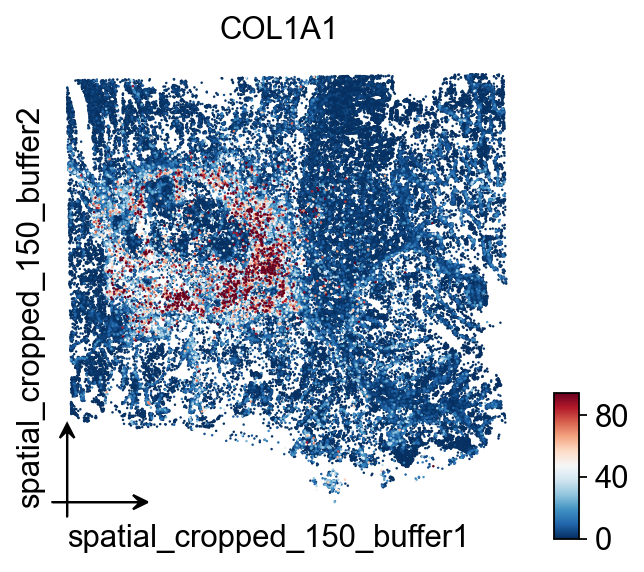

In [12]:
ov.pl.embedding(
    cdata,
    basis='spatial_cropped_150_buffer',
    color=['COL1A1'],
    vmax='p99.2',cmap='RdBu_r',
    size=5,
)

## Visualization

In [13]:
#define a mask to easily pull out this region of the object in the future
mask = ((adata.obs['array_row'] >= 2225) & 
        (adata.obs['array_row'] <= 2275) & 
        (adata.obs['array_col'] >= 1400) & 
        (adata.obs['array_col'] <= 1450))
print(f'Subregion: {mask.sum()} bins')

Subregion: 2601 bins


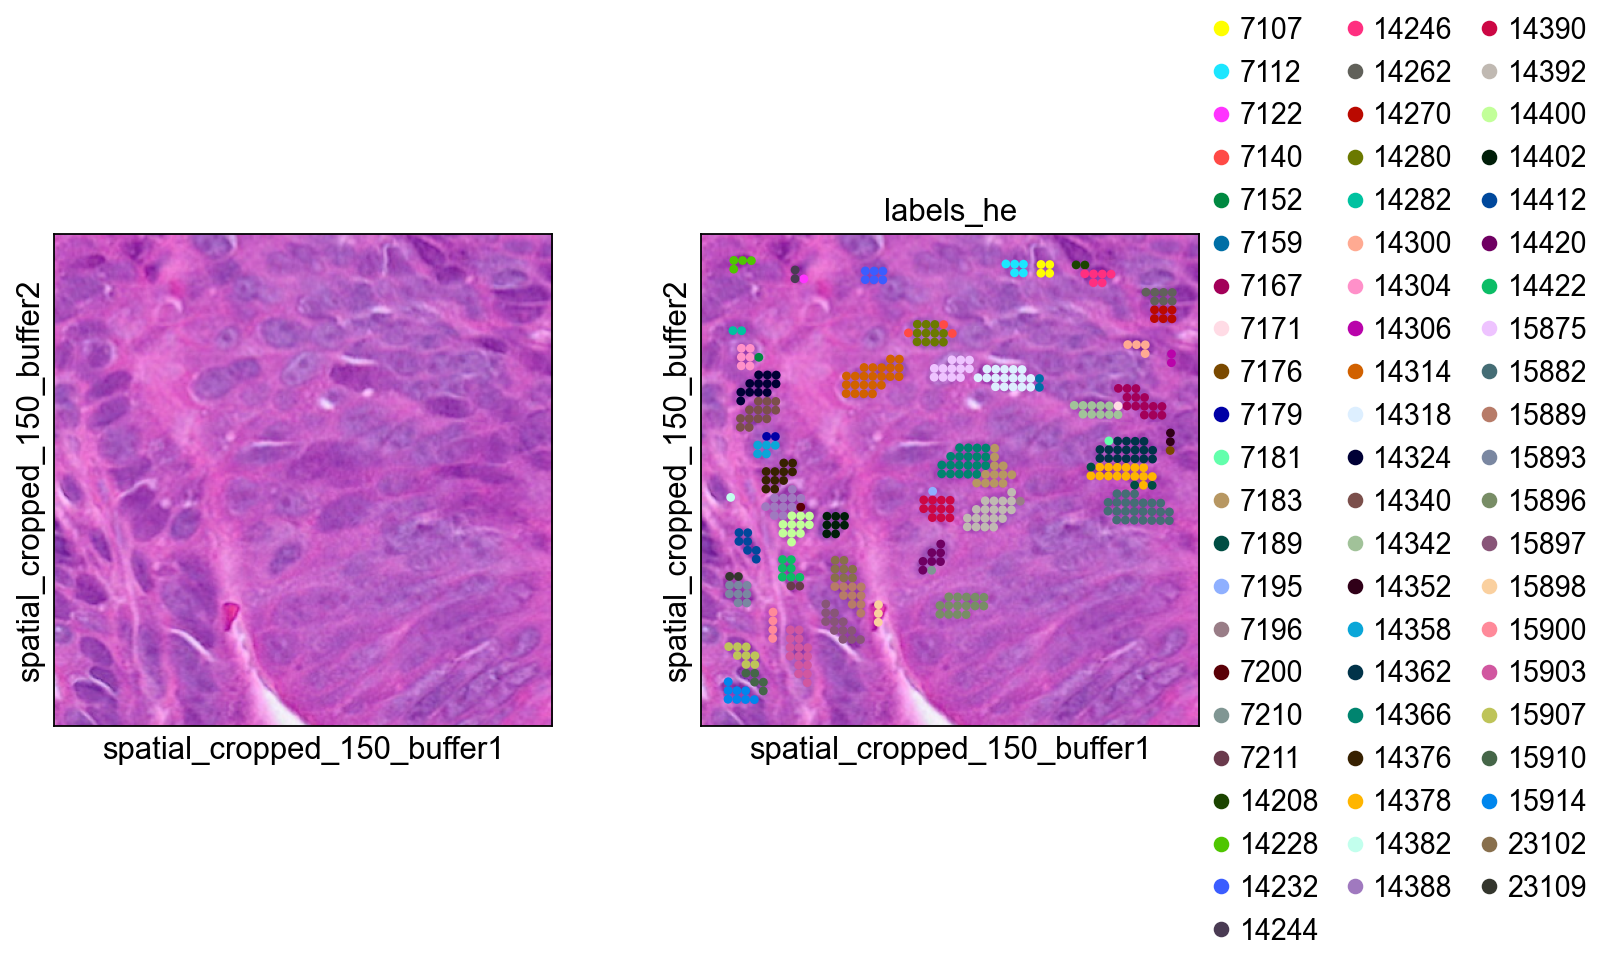

In [14]:

bdata = adata[mask]
#0 means unassigned
bdata = bdata[bdata.obs['labels_he']>0]
bdata.obs['labels_he'] = bdata.obs['labels_he'].astype(str)

sc.pl.spatial(bdata, color=[None, "labels_he"], img_key="0.3_mpp_150_buffer", 
              basis="spatial_cropped_150_buffer")

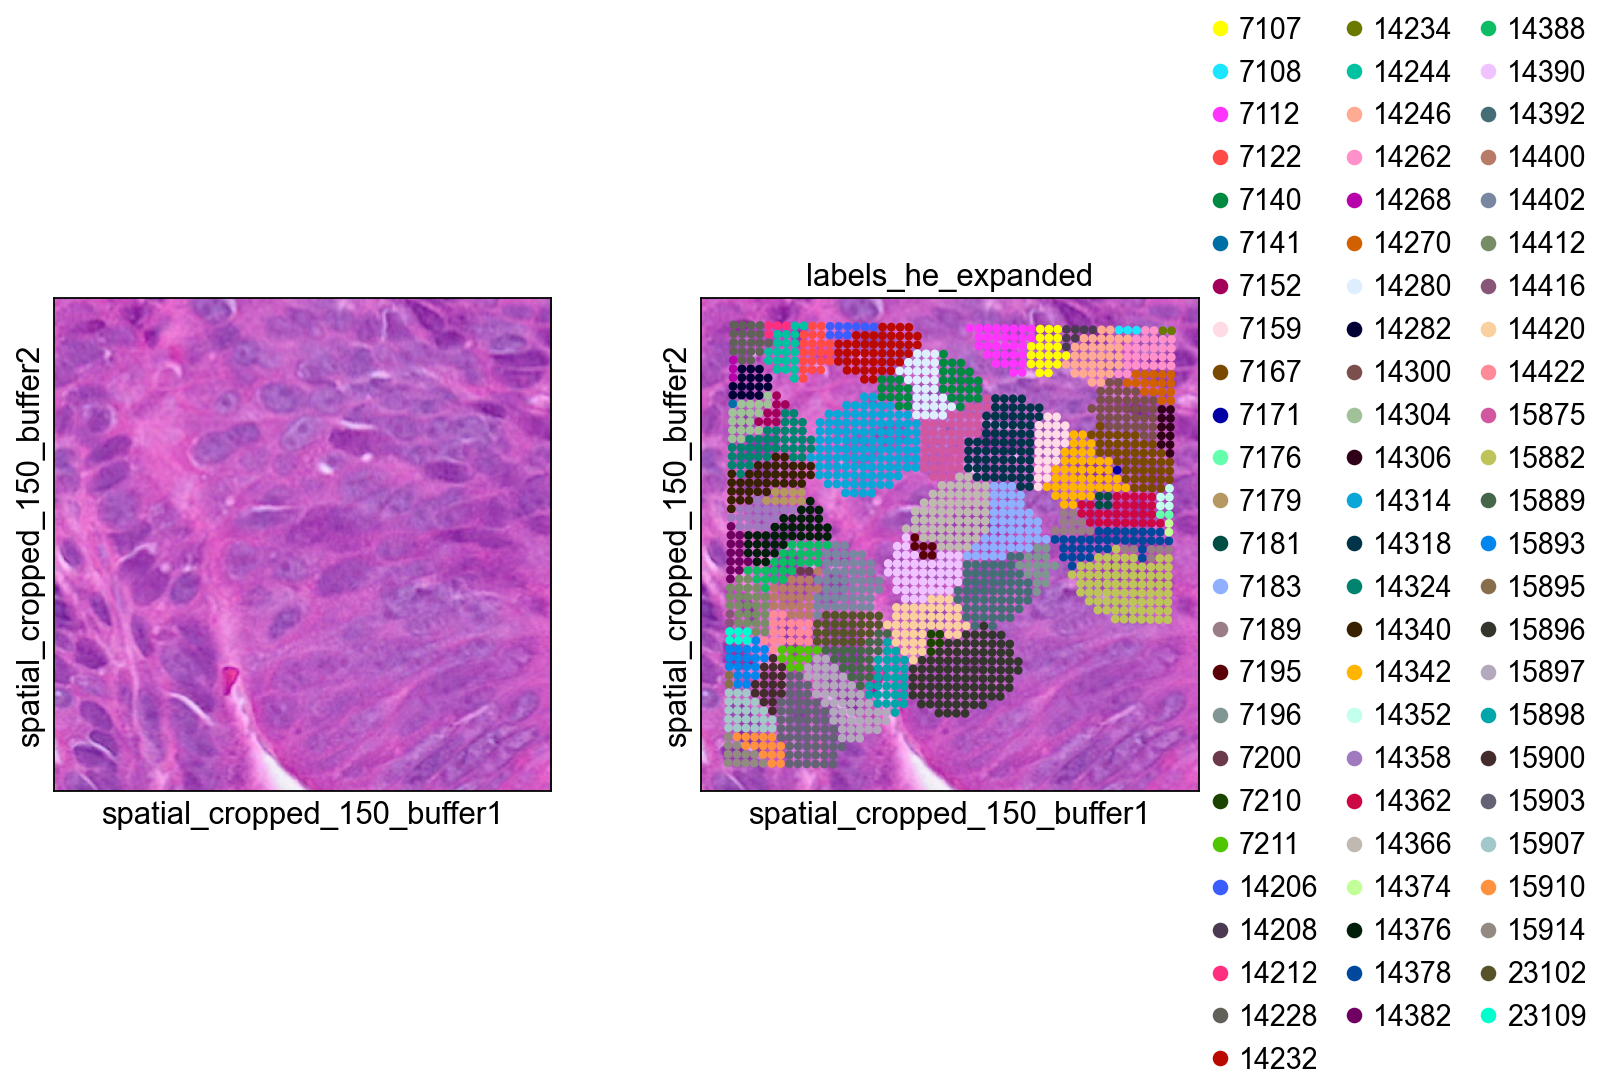

In [15]:
bdata = adata[mask]
#0 means unassigned
bdata = bdata[bdata.obs['labels_he_expanded']>0]
bdata.obs['labels_he_expanded'] = bdata.obs['labels_he_expanded'].astype(str)

sc.pl.spatial(bdata, color=[None, "labels_he_expanded"], img_key="0.3_mpp_150_buffer", 
              basis="spatial_cropped_150_buffer")

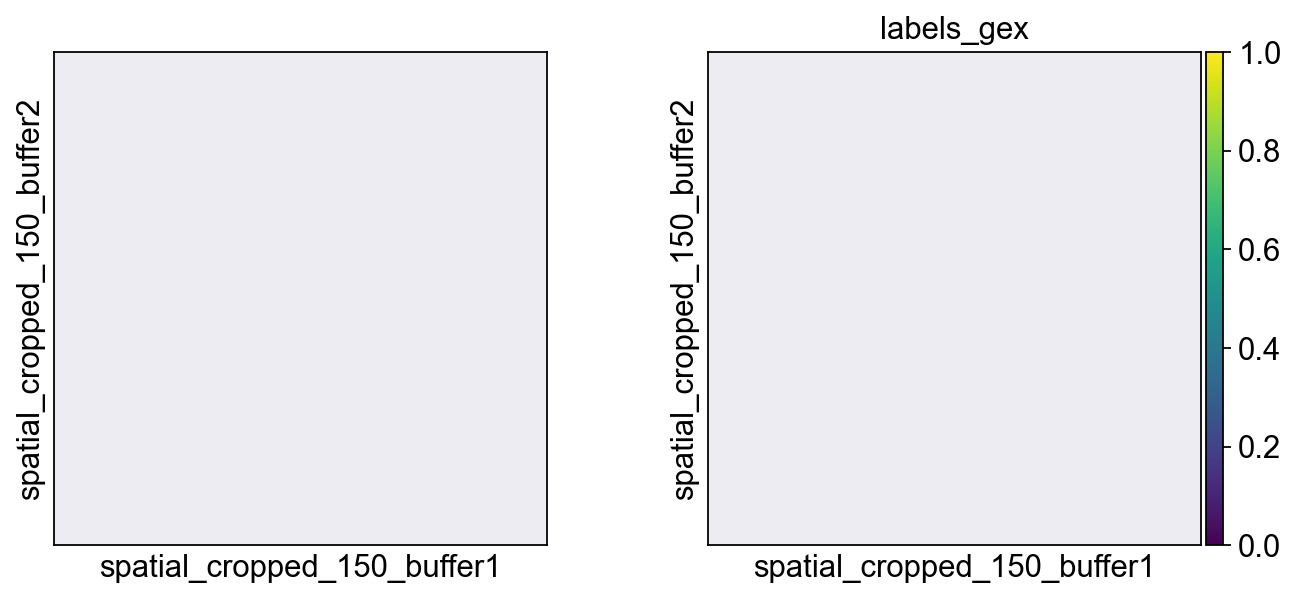

In [16]:
bdata = adata[mask]
#0 means unassigned
bdata = bdata[bdata.obs['labels_gex']>0]
bdata.obs['labels_gex'] = bdata.obs['labels_gex'].astype(str)

sc.pl.spatial(bdata, color=[None, "labels_gex"], img_key="0.3_mpp_150_buffer", 
              basis="spatial_cropped_150_buffer")

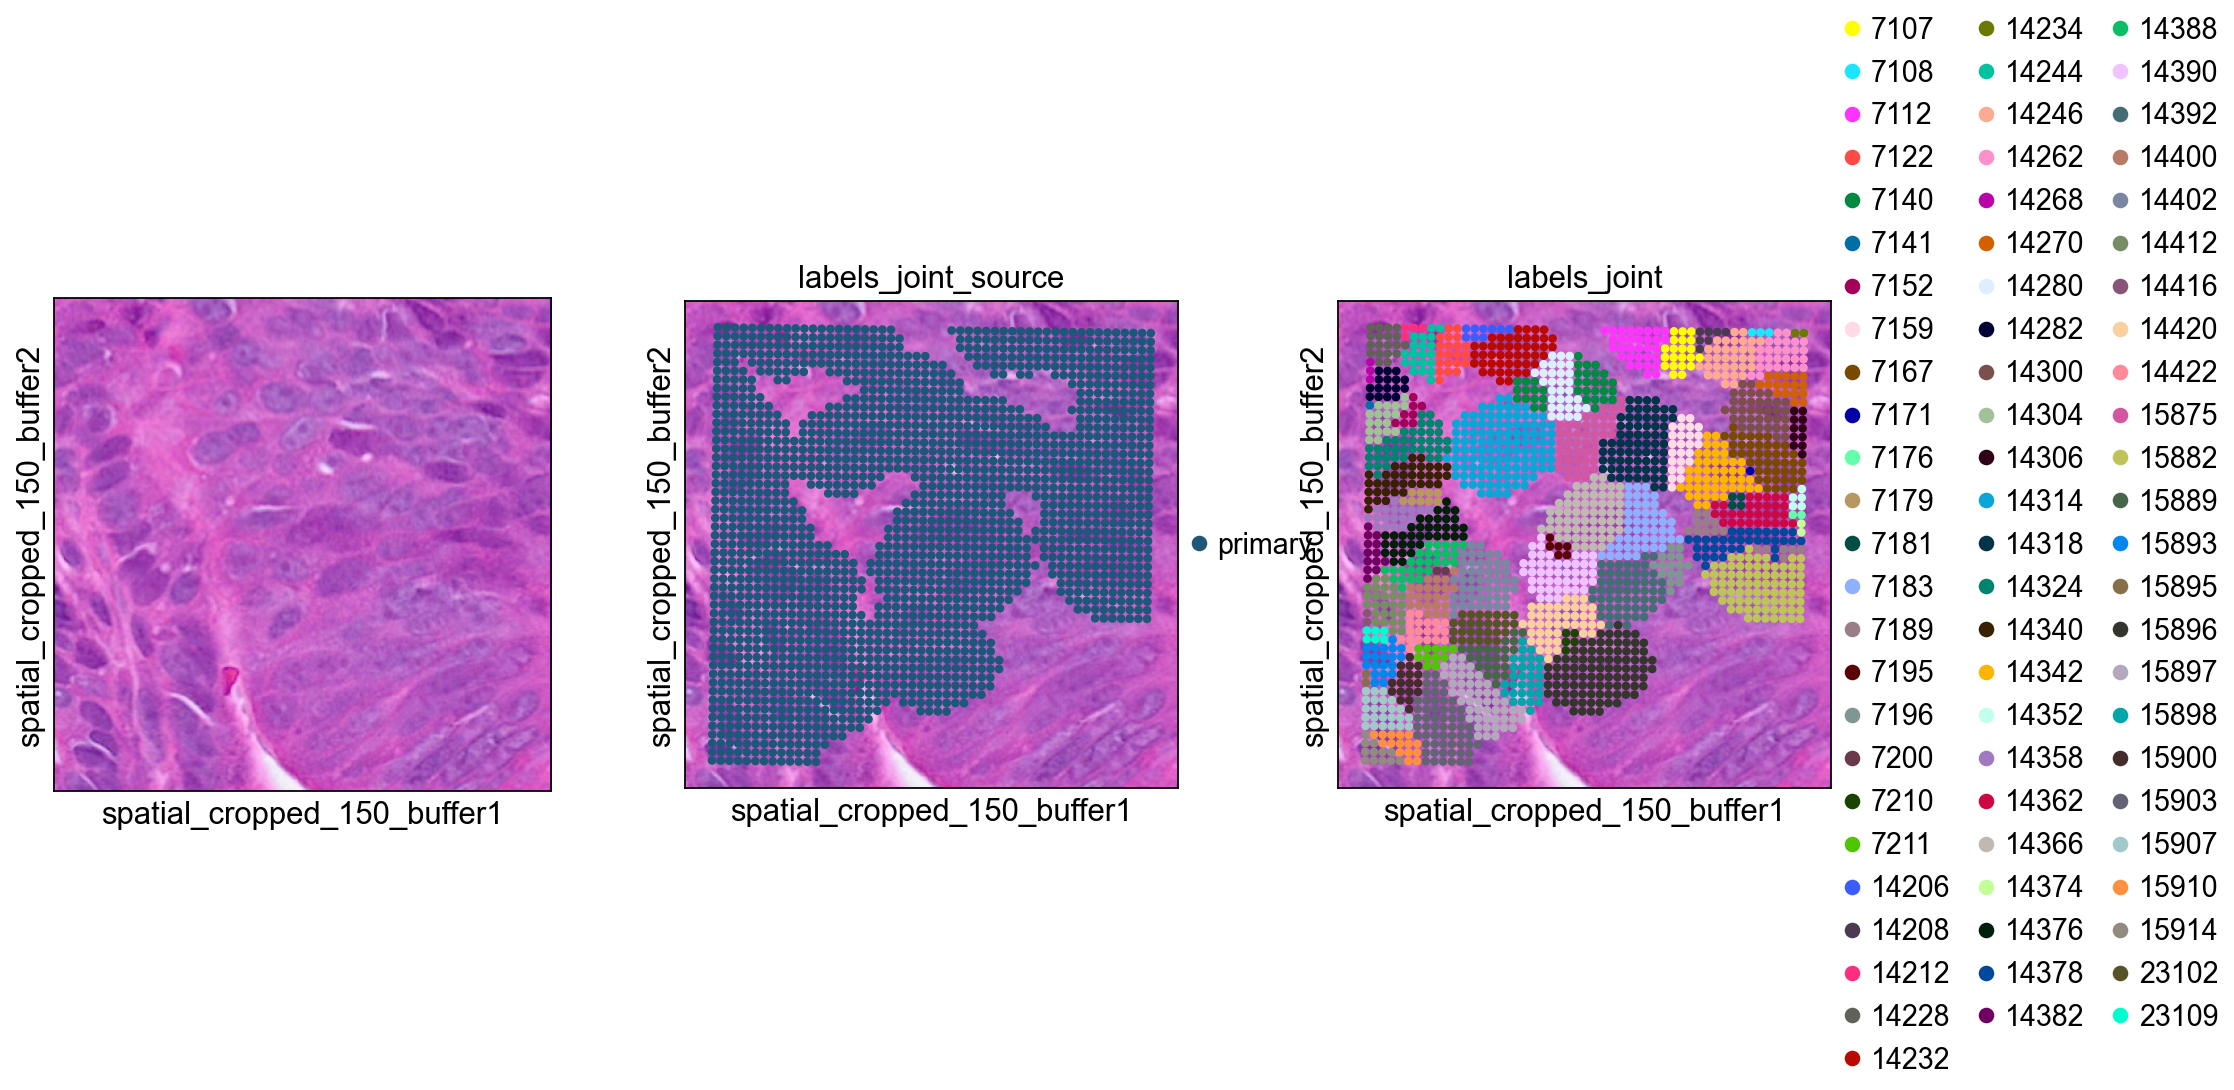

In [17]:
bdata = adata[mask]

#0 means unassigned
bdata = bdata[bdata.obs['labels_joint']>0]
bdata.obs['labels_joint'] = bdata.obs['labels_joint'].astype(str)

sc.pl.spatial(bdata, color=[None, "labels_joint_source", 
                            "labels_joint"], img_key="0.3_mpp_150_buffer", 
              basis="spatial_cropped_150_buffer")

## Export to SpaceRanger v4 Format

`ov.space.write_visium_hd_cellseg()` exports the cell-level AnnData to a directory structure matching SpaceRanger v4 segmented output. This makes the Cellpose-derived segmentation portable: any tool that already understands SpaceRanger v4 cell-segmentation output can read these results back, including `ov.io.read_visium_hd(data_type='cellseg')`.

**Important:** use `spatial_keys=['spatial']` and `geometry_spatial_key='spatial'` in `bin2cell()` for the export object so that coordinates stay aligned with the hires/lowres images and scalefactors.

In [18]:
# Re-run bin2cell with fullres spatial coords for SpaceRanger-compatible export
cdata_export = ov.space.bin2cell(
    adata, labels_key='labels_joint',
    spatial_keys=['spatial'],
    add_geometry=True,
    geometry_spatial_key='spatial',
)
cdata_export

bin_to_cell:   0%|          | 0/7 [00:00<?, ?it/s]

bin2cell geometry:   0%|          | 0/84853 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 84853 × 18058
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'geometry', 'cellid'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'omicverse_io'
    obsm: 'spatial'

In [19]:
ov.space.write_visium_hd_cellseg(cdata_export, 'cellpose_spaceranger_output')

[VisiumHD][INFO] Exporting to SpaceRanger v4 format: cellpose_spaceranger_output
[VisiumHD][INFO] Writing count matrix: cellpose_spaceranger_output/filtered_feature_cell_matrix.h5


[VisiumHD][INFO] Writing segmentation GeoJSON: cellpose_spaceranger_output/graphclust_annotated_cell_segmentations.geojson


[VisiumHD][INFO]   63410 cell polygons written


[VisiumHD][INFO]   Saved tissue_hires_image.png
[VisiumHD][INFO]   Saved tissue_lowres_image.png
[VisiumHD][INFO]   Saved scalefactors_json.json
[VisiumHD][OK] Export complete: cellpose_spaceranger_output


### Verify the exported directory structure

In [20]:
from pathlib import Path

for f in sorted(Path('cellpose_spaceranger_output').rglob('*')):
    if f.is_file():
        size = f.stat().st_size
        print(f'  {f.relative_to("cellpose_spaceranger_output")}: {size:,} bytes')

  filtered_feature_cell_matrix.h5: 891,193,118 bytes
  graphclust_annotated_cell_segmentations.geojson: 84,487,544 bytes
  spatial/scalefactors_json.json: 339 bytes
  spatial/tissue_hires_image.png: 31,418,155 bytes
  spatial/tissue_lowres_image.png: 289,844 bytes


## Read Back with `ov.io.read_visium_hd`

The exported directory can be read back with the same API used for native SpaceRanger v4 cell-segmentation output.

In [21]:
cdata_read = ov.io.read_visium_hd(
    'cellpose_spaceranger_output',
    data_type='cellseg',
)
cdata_read

[VisiumHD][INFO] read_visium_hd entry (data_type='cellseg')
[VisiumHD][START] Reading cell-segmentation data from: /scratch/users/steorra/analysis/25_pantheon_case/data_HD_sp/cellpose_spaceranger_output
[VisiumHD][INFO] Sample key: cellpose_spaceranger_output


[VisiumHD][STEP] Loading segmentation geometry: /scratch/users/steorra/analysis/25_pantheon_case/data_HD_sp/cellpose_spaceranger_output/graphclust_annotated_cell_segmentations.geojson


[VisiumHD][STEP] Loading count matrix: /scratch/users/steorra/analysis/25_pantheon_case/data_HD_sp/cellpose_spaceranger_output/filtered_feature_cell_matrix.h5


[VisiumHD][STEP] Loading images and scale factors


[VisiumHD][OK] Done (n_obs=63410, n_vars=18058)


AnnData object with n_obs × n_vars = 63410 × 18058
    obs: 'geometry'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'omicverse_io'
    obsm: 'spatial'

In [22]:
# Note: cells without geometry (e.g. single-bin cells) are excluded
# from the GeoJSON, so the read-back may have fewer cells.
print(f'Exported: {cdata_export.shape[0]} cells')
print(f'Read back: {cdata_read.shape[0]} cells')
print(f'Cell IDs match (subset): {set(cdata_read.obs_names).issubset(set(cdata_export.obs_names))}')


Exported: 84853 cells
Read back: 63410 cells
Cell IDs match (subset): True


### Visualize the re-imported data

These spatial plots confirm that the exported cell coordinates still align correctly with the H&E background after round-tripping through the SpaceRanger-style directory structure.

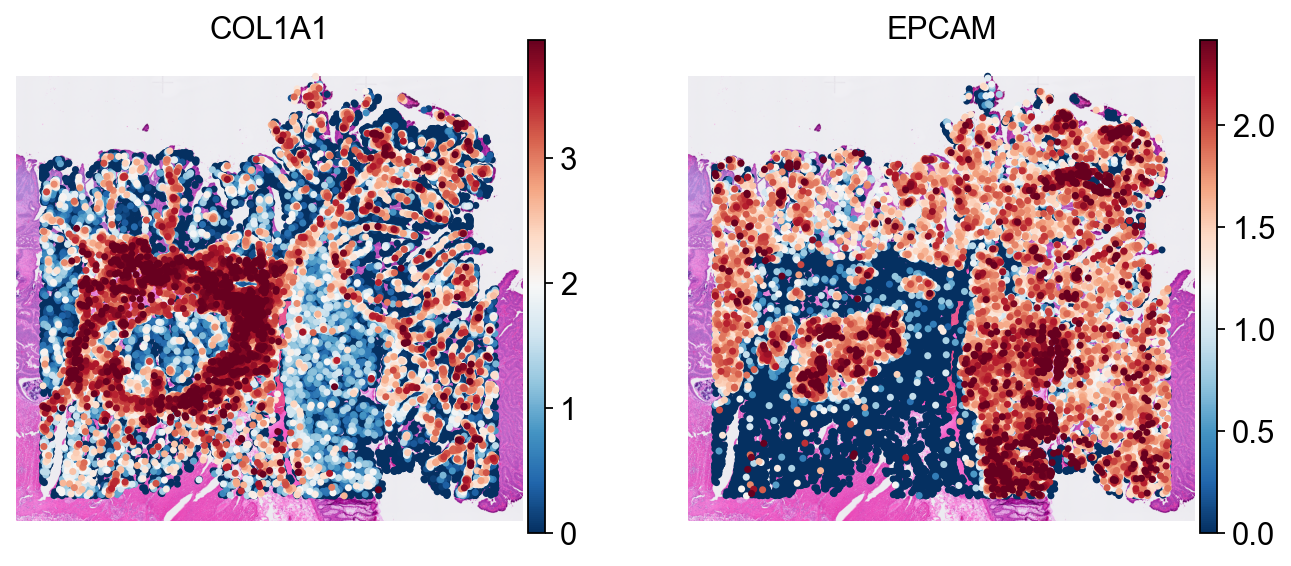

In [23]:
sc.pp.normalize_total(cdata_read)
sc.pp.log1p(cdata_read)

sc.pl.spatial(
    cdata_read, color=['COL1A1', 'EPCAM'],
    size=8, linewidth=0, img_key='hires',
    frameon=False, cmap='RdBu_r', vmax='p99',
)

## Cellpose vs CellSAM Comparison

[CellSAM](https://www.nature.com/articles/s41592-025-02879-w) (Nature Methods 2025) is a foundation model for cell segmentation. To get a more concrete sense of the trade-off between backends, we compare Cellpose and CellSAM on the same 1024×1024 tissue crop.

In [24]:
import numpy as np
import scipy.sparse, tifffile, zarr
from skimage.segmentation import find_boundaries
from omicverse.external.bin2cell import cellseg

# Read a 1024x1024 crop from the mpp-scaled H&E
with tifffile.TiffFile('stardist/he_colon1.tiff') as tif:
    z = zarr.open(tif.pages[0].aszarr(), mode='r')
    h, w = z.shape[:2]
    crop = np.array(z[h//2-512:h//2+512, w//2-512:w//2+512, :3])
tifffile.imwrite('stardist/cmp_crop.tiff', crop)
print(f'Crop: {crop.shape}')

Crop: (1024, 1024, 3)


In [25]:
# Cellpose
cellseg('stardist/cmp_crop.tiff', 'stardist/cmp_cp.npz',
        backend='cellpose', block_size=1024, gpu=True, flow_threshold=0.4)
cp = scipy.sparse.load_npz('stardist/cmp_cp.npz').toarray()
print(f'Cellpose: {cp.max()} cells')

# CellSAM
cellseg('stardist/cmp_crop.tiff', 'stardist/cmp_cs.npz',
        backend='cellsam', block_size=1024, gpu=True)
cs = scipy.sparse.load_npz('stardist/cmp_cs.npz').toarray()
print(f'CellSAM: {cs.max()} cells')

model_type argument is not used in v4.0.1+. Ignoring this argument...


bin2cell.cellseg:   0%|                                                                                              | 0/1 [00:00<?, ?tile/s]

bin2cell.cellseg: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.19s/tile]

bin2cell.cellseg: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.19s/tile]

Cellpose: 318 cells


...

bin2cell.cellsam:   0%|                                                                                              | 0/1 [00:00<?, ?tile/s]

bin2cell.cellsam: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:57<00:00, 57.57s/tile]

bin2cell.cellsam: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:57<00:00, 57.57s/tile]

CellSAM segmentation complete: 482 cells


CellSAM: 482 cells


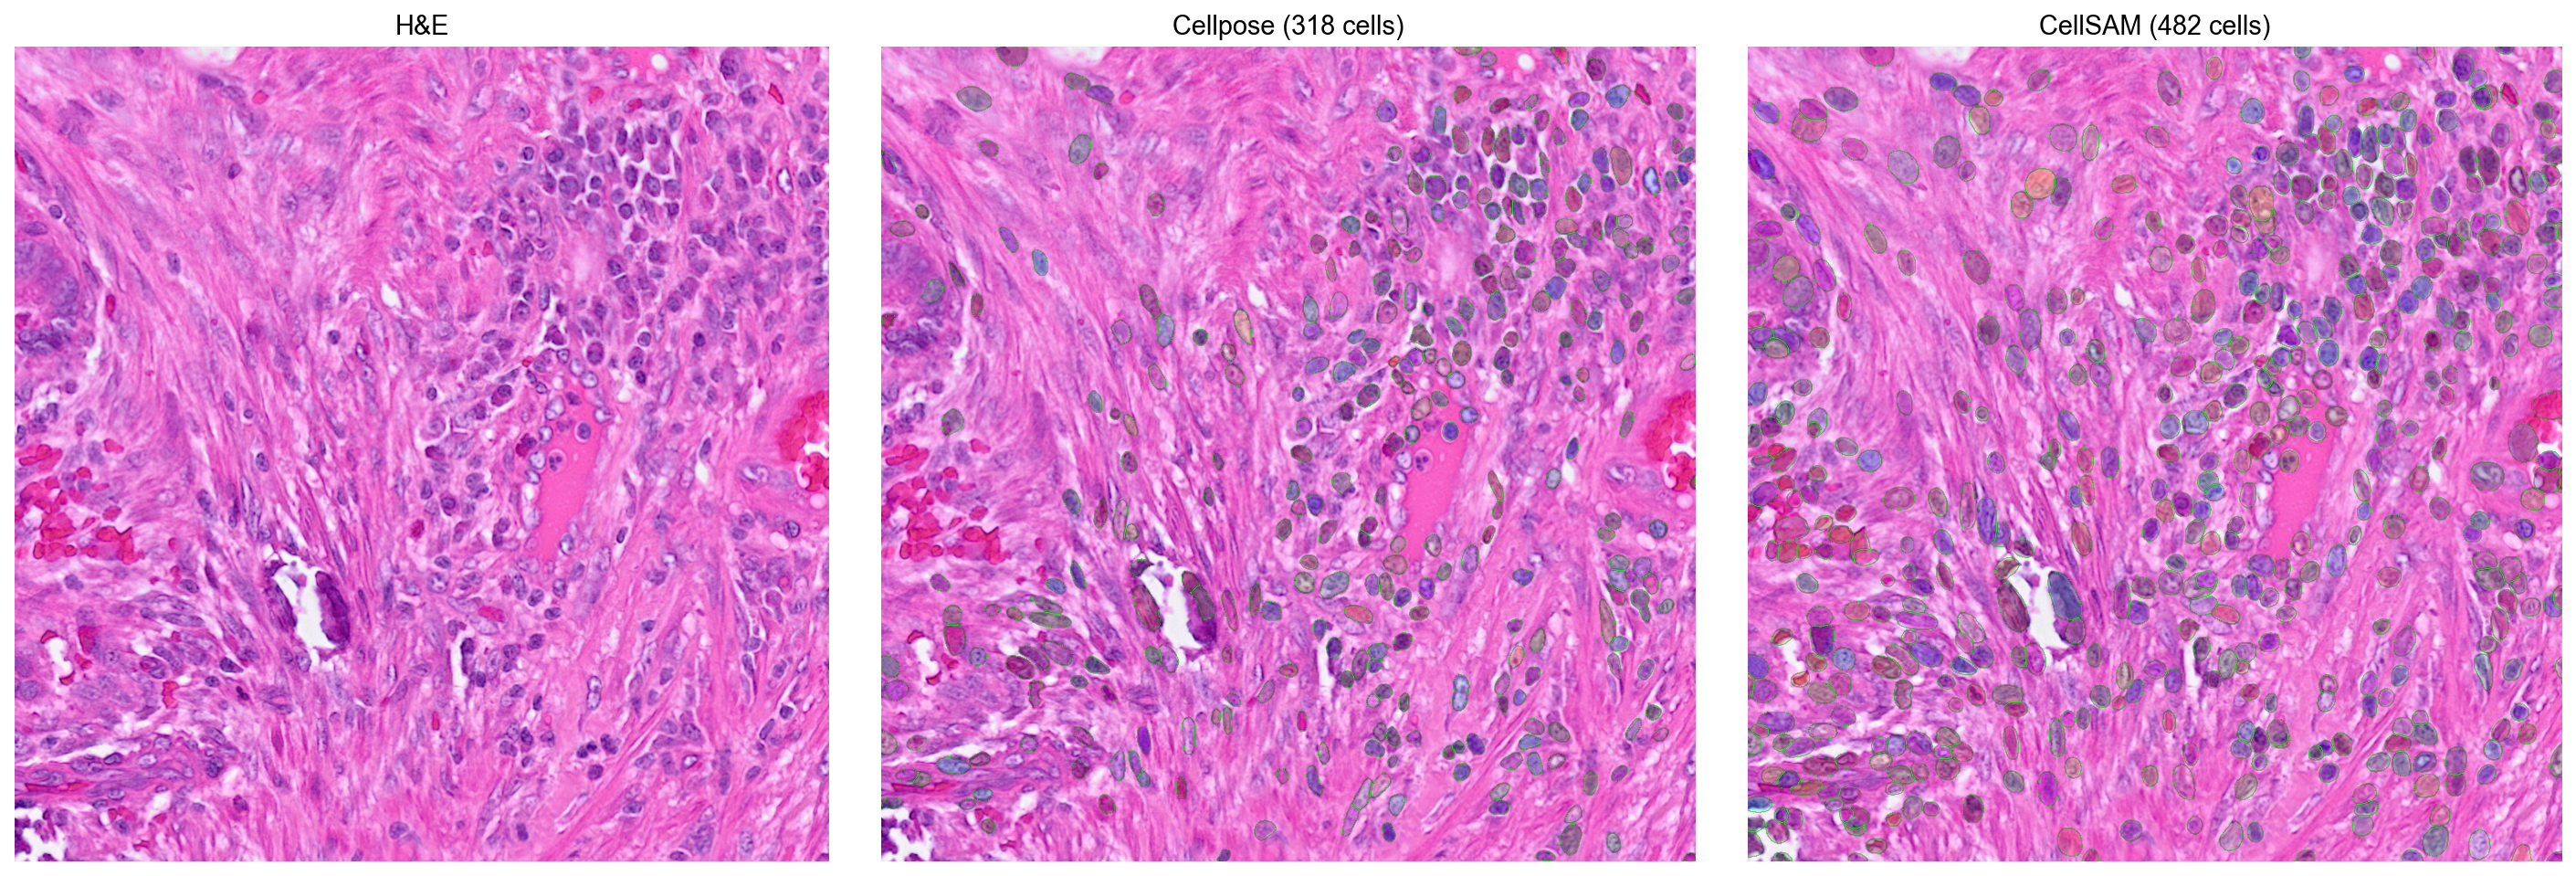

In [26]:
import matplotlib.pyplot as plt

def _overlay(ax, img, labels, title):
    ax.imshow(img)
    bnd = find_boundaries(labels, mode='outer')
    rng = np.random.RandomState(42)
    c = rng.rand(labels.max()+1, 4); c[:,3]=0.25; c[0]=[0,0,0,0]
    ax.imshow(c[labels])
    b = np.zeros((*labels.shape, 4)); b[bnd]=[0,1,0,0.8]
    ax.imshow(b)
    ax.set_title(title, fontsize=13, fontweight='bold'); ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(crop)
axes[0].set_title('H&E', fontsize=13, fontweight='bold')
axes[0].axis('off')
_overlay(axes[1], crop, cp, f'Cellpose ({cp.max()} cells)')
_overlay(axes[2], crop, cs, f'CellSAM ({cs.max()} cells)')
plt.tight_layout()
plt.show()

### Cell-level spatial comparison

Aggregate both segmentation results from the 1024×1024 crop into cell-level expression objects so that the two backends can be compared in the same spatial gene-expression view.

In [27]:
import numpy as np

# Build minimal bin-level adata for the crop region
# The crop covers spatial_cropped rows [cy-512:cy+512, cx-512:cx+512] in mpp space
sp = adata.obsm['spatial_cropped_150_buffer']
sample = list(adata.uns['spatial'].keys())[0]
mpp_sf = adata.uns['spatial'][sample]['scalefactors'].get(
    'tissue_0.3_mpp_150_buffer_scalef', 0.91)
import tifffile
with tifffile.TiffFile('stardist/he_colon1.tiff') as t:
    h, w = t.pages[0].shape[:2]
cy, cx = h//2, w//2

# Select bins whose mpp-scaled coords fall within the crop
scaled = sp * mpp_sf
cmask = ((scaled[:,1] >= cy-512) & (scaled[:,1] < cy+512) &
         (scaled[:,0] >= cx-512) & (scaled[:,0] < cx+512))
adata_sub = adata[cmask].copy()
print(f'Crop bins: {adata_sub.shape[0]}')

# Cellpose labels are already in adata from the full pipeline
# bin_to_cell using the existing labels_he_expanded
cdata_cp = ov.space.bin2cell(adata_sub, labels_key='labels_he_expanded',
                      spatial_keys=['spatial_cropped_150_buffer'])
sc.pp.normalize_total(cdata_cp); sc.pp.log1p(cdata_cp)
print(f'Cellpose cells: {cdata_cp.shape[0]}')

Crop bins: 23295


bin_to_cell:   0%|          | 0/7 [00:00<?, ?it/s]

bin2cell geometry:   0%|          | 0/428 [00:00<?, ?it/s]

Cellpose cells: 428


In [28]:
# CellSAM: insert labels from the crop npz
from omicverse.external.bin2cell import insert_labels, expand_labels
import scipy.sparse

# Map bin spatial coords to crop pixel coords
crop_origin = np.array([cx-512, cy-512])
crop_px = (adata_sub.obsm['spatial_cropped_150_buffer'] * mpp_sf - crop_origin).astype(int)

cs_labels = scipy.sparse.load_npz('stardist/cmp_cs.npz')
lab_vals = np.zeros(len(adata_sub), dtype=int)
valid = ((crop_px[:,0] >= 0) & (crop_px[:,0] < cs_labels.shape[1]) &
         (crop_px[:,1] >= 0) & (crop_px[:,1] < cs_labels.shape[0]))
if valid.any():
    v = cs_labels[crop_px[valid,1], crop_px[valid,0]]
    if scipy.sparse.issparse(v):
        v = np.asarray(v.todense()).flatten()
    else:
        v = np.asarray(v).flatten()
    lab_vals[valid] = v
adata_sub.obs['labels_cellsam'] = lab_vals

expand_labels(adata_sub, labels_key='labels_cellsam',
              expanded_labels_key='labels_cellsam_exp', max_bin_distance=2)

cdata_cs = ov.space.bin2cell(adata_sub, labels_key='labels_cellsam_exp',
                      spatial_keys=['spatial_cropped_150_buffer'])
sc.pp.normalize_total(cdata_cs); sc.pp.log1p(cdata_cs)
print(f'CellSAM cells: {cdata_cs.shape[0]}')

bin_to_cell:   0%|          | 0/7 [00:00<?, ?it/s]

bin2cell geometry:   0%|          | 0/482 [00:00<?, ?it/s]

CellSAM cells: 482


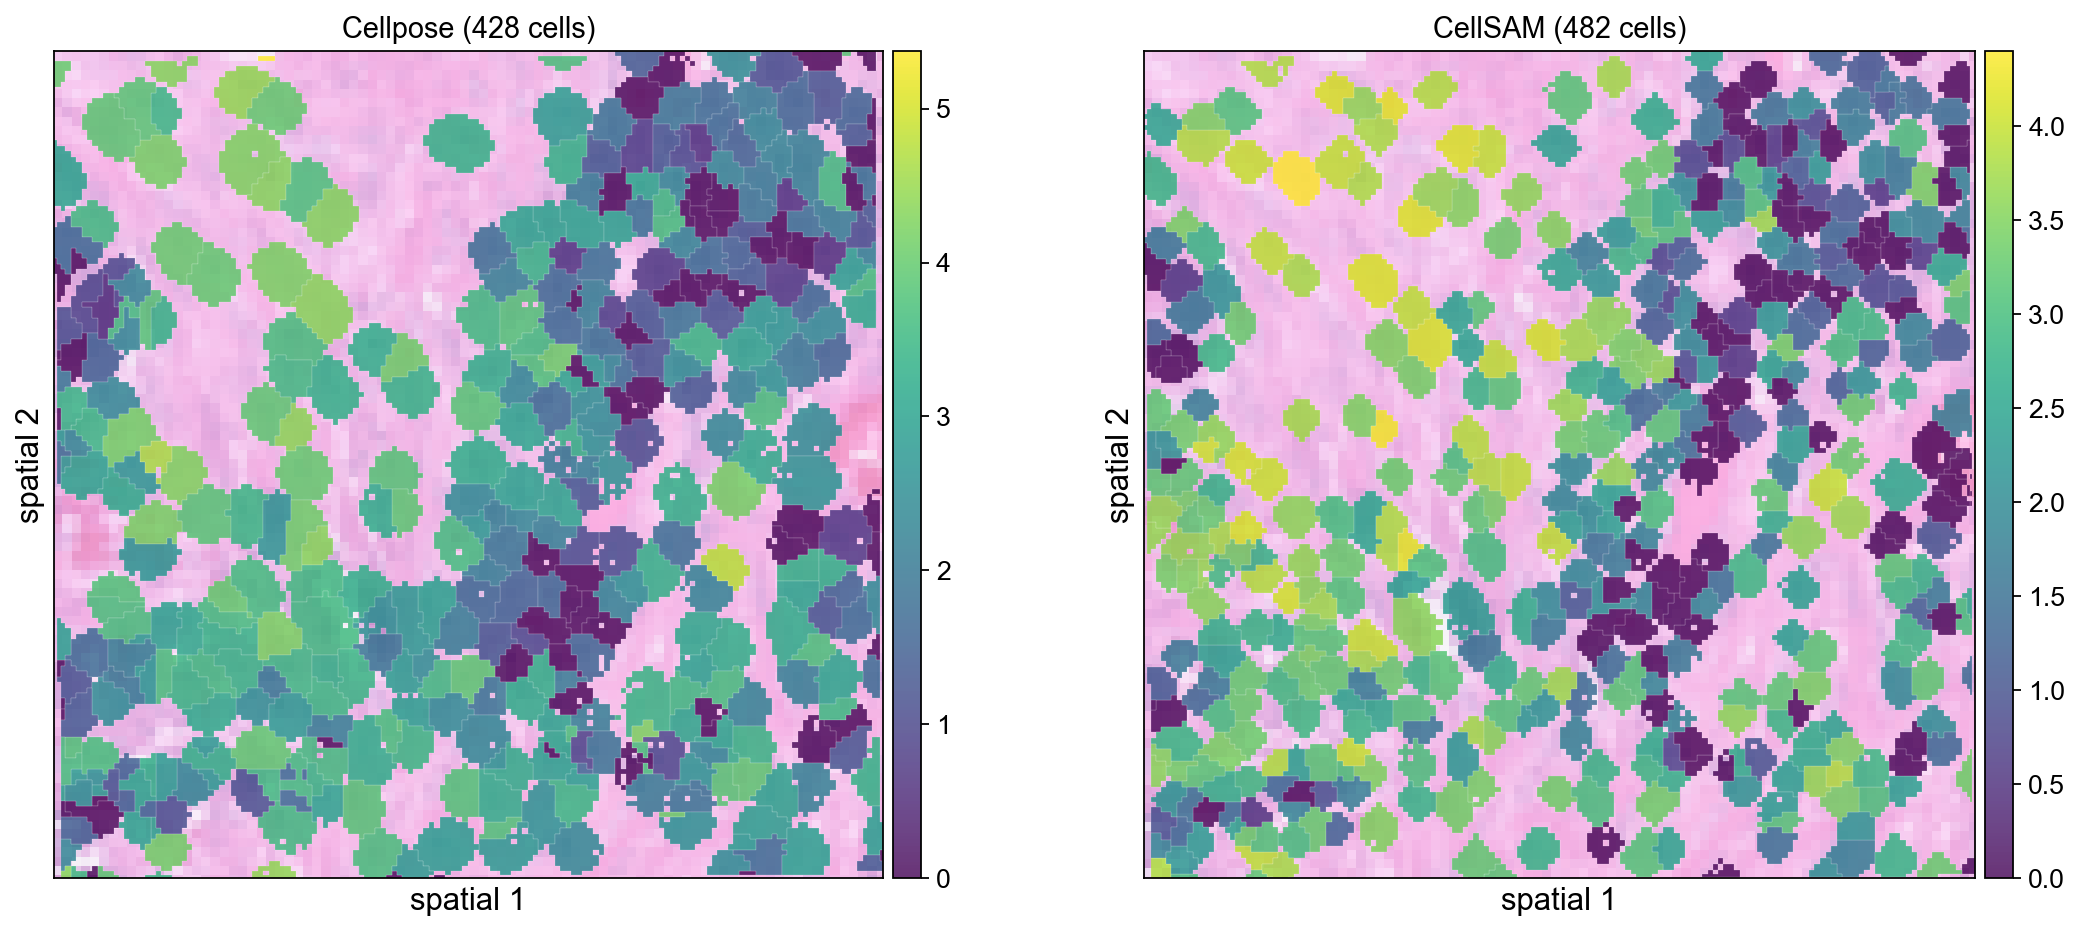

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ov.pl.spatialseg(cdata_cp, color='COL1A1', edges_color='white',
                 edges_width=0.1, alpha=0.8, ax=axes[0], show=False)
axes[0].set_title(f'Cellpose ({cdata_cp.shape[0]} cells)', fontsize=13)
ov.pl.spatialseg(cdata_cs, color='COL1A1', edges_color='white',
                 edges_width=0.1, alpha=0.8, ax=axes[1], show=False)
axes[1].set_title(f'CellSAM ({cdata_cs.shape[0]} cells)', fontsize=13)
plt.tight_layout()
plt.show()